# Semana 1 — EDA: Predictor de Churn

**Objetivo:** Entender los datos antes de tocar cualquier modelo.  
**Dataset:** Telco Customer Churn (Kaggle)  
**Pregunta guía:** ¿Qué variables parecen más relacionadas con que un cliente se vaya?

---

## 0. Instalación y carga de datos

Sube el archivo `WA_Fn-UseC_-Telco-Customer-Churn.csv` descargado de Kaggle:  
**Kaggle → Datasets → busca 'Telco Customer Churn' → Download**

Luego súbelo a Colab con el bloque de abajo.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('telco.csv')
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
df.head(3)

Filas: 7,043  |  Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


---
## 1. Vista general del dataset

In [6]:
# Tipos de datos y valores nulos
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    '% nulo': (df.isnull().mean() * 100).round(2),
    'únicos': df.nunique()
})
print(info.to_string())

                    dtype  nulos  % nulo  únicos
customerID            str      0     0.0    7043
gender                str      0     0.0       2
SeniorCitizen       int64      0     0.0       2
Partner               str      0     0.0       2
Dependents            str      0     0.0       2
tenure              int64      0     0.0      73
PhoneService          str      0     0.0       2
MultipleLines         str      0     0.0       3
InternetService       str      0     0.0       3
OnlineSecurity        str      0     0.0       3
OnlineBackup          str      0     0.0       3
DeviceProtection      str      0     0.0       3
TechSupport           str      0     0.0       3
StreamingTV           str      0     0.0       3
StreamingMovies       str      0     0.0       3
Contract              str      0     0.0       3
PaperlessBilling      str      0     0.0       2
PaymentMethod         str      0     0.0       4
MonthlyCharges    float64      0     0.0    1585
TotalCharges        

In [7]:
# TotalCharges viene como string — corregir
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

nulos_total = df['TotalCharges'].isnull().sum()
print(f'Nulos en TotalCharges tras conversión: {nulos_total}')
print('Son clientes con tenure=0 (recién ingresaron):')
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head())

Nulos en TotalCharges tras conversión: 11
Son clientes con tenure=0 (recién ingresaron):
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN


In [8]:
# Convertir variable objetivo a binaria (0/1)
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

churn_rate = df['Churn_bin'].mean()
print(f'Tasa de churn: {churn_rate:.1%}')
print(f'Clientes que se fueron: {df["Churn_bin"].sum():,}')
print(f'Clientes que se quedaron: {(df["Churn_bin"]==0).sum():,}')

Tasa de churn: 26.5%
Clientes que se fueron: 1,869
Clientes que se quedaron: 5,174


---
## 2. Distribución de la variable objetivo

> visualizar el desbalance antes de modelar.  

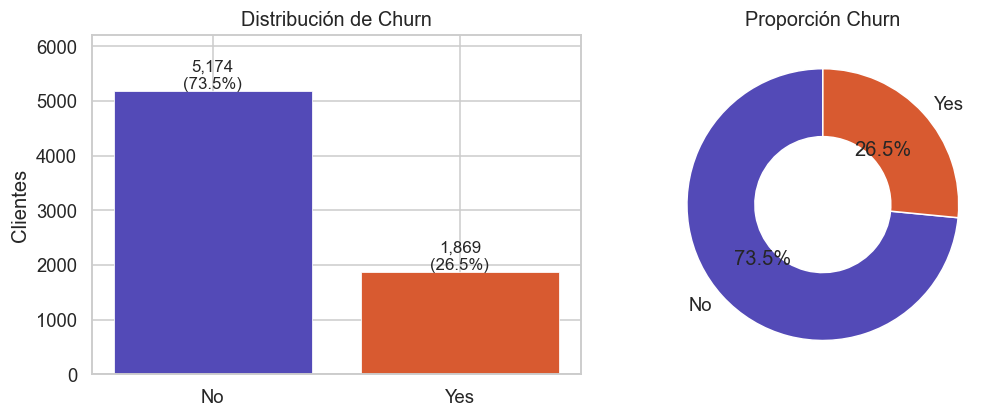


→ Dataset desbalanceado: ~26% churn. Accuracy NO será nuestra métrica principal.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barras
counts = df['Churn'].value_counts()
colors = ['#534AB7', '#D85A30']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=11)
axes[0].set_title('Distribución de Churn', fontsize=13)
axes[0].set_ylabel('Clientes')
axes[0].set_ylim(0, counts.max() * 1.2)

# Donut
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.5, edgecolor='white'))
axes[1].set_title('Proporción Churn', fontsize=13)

plt.tight_layout()
plt.savefig('plot_01_distribucion_churn.png', bbox_inches='tight')
plt.show()
print('\n→ Dataset desbalanceado: ~26% churn. Accuracy NO será nuestra métrica principal.')

---
## 3. Variables numéricas: distribución por grupo

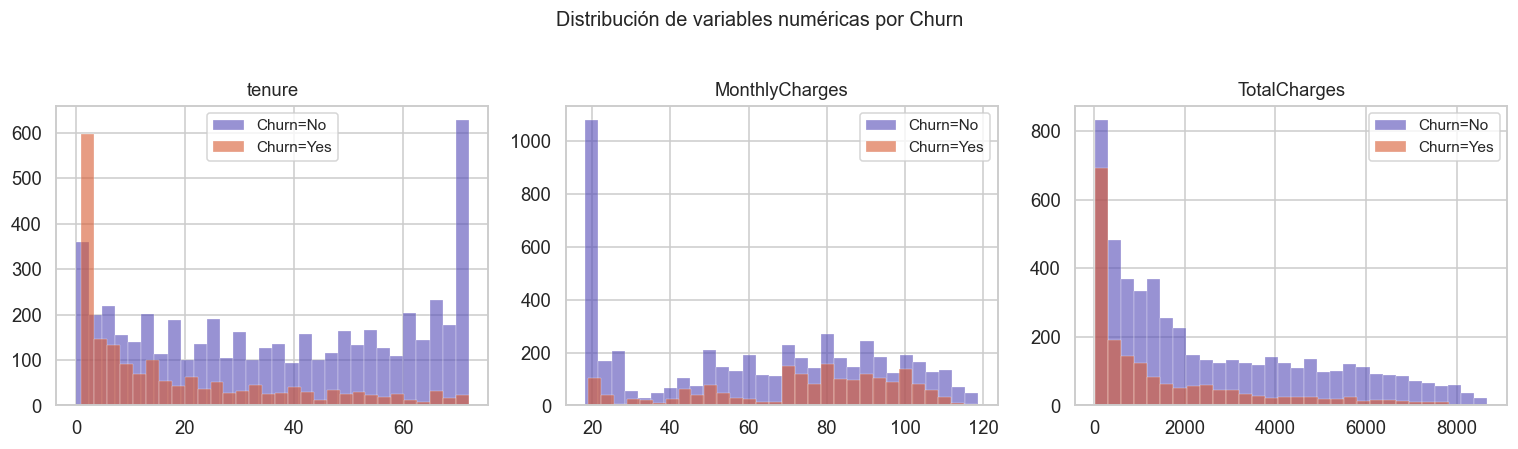

In [10]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, num_cols):
    for label, color in [('No', '#534AB7'), ('Yes', '#D85A30')]:
        subset = df[df['Churn'] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label=f'Churn={label}', edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.legend(fontsize=10)

plt.suptitle('Distribución de variables numéricas por Churn', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_02_numericas_churn.png', bbox_inches='tight')
plt.show()

In [11]:
# Estadísticas por grupo
print('Medias por grupo (Churn Yes vs No):')
print(df.groupby('Churn')[num_cols].mean().round(2).to_string())

print('\n→ Observaciones:')
print('  - Clientes con churn tienen tenure MÁS BAJO (llevan menos tiempo)')
print('  - Clientes con churn tienen MonthlyCharges MÁS ALTO')
print('  - TotalCharges es consecuencia de las dos anteriores')

Medias por grupo (Churn Yes vs No):
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2555.34
Yes     17.98           74.44       1531.80

→ Observaciones:
  - Clientes con churn tienen tenure MÁS BAJO (llevan menos tiempo)
  - Clientes con churn tienen MonthlyCharges MÁS ALTO
  - TotalCharges es consecuencia de las dos anteriores


---
## 4. Variables categóricas: tasa de churn por categoría

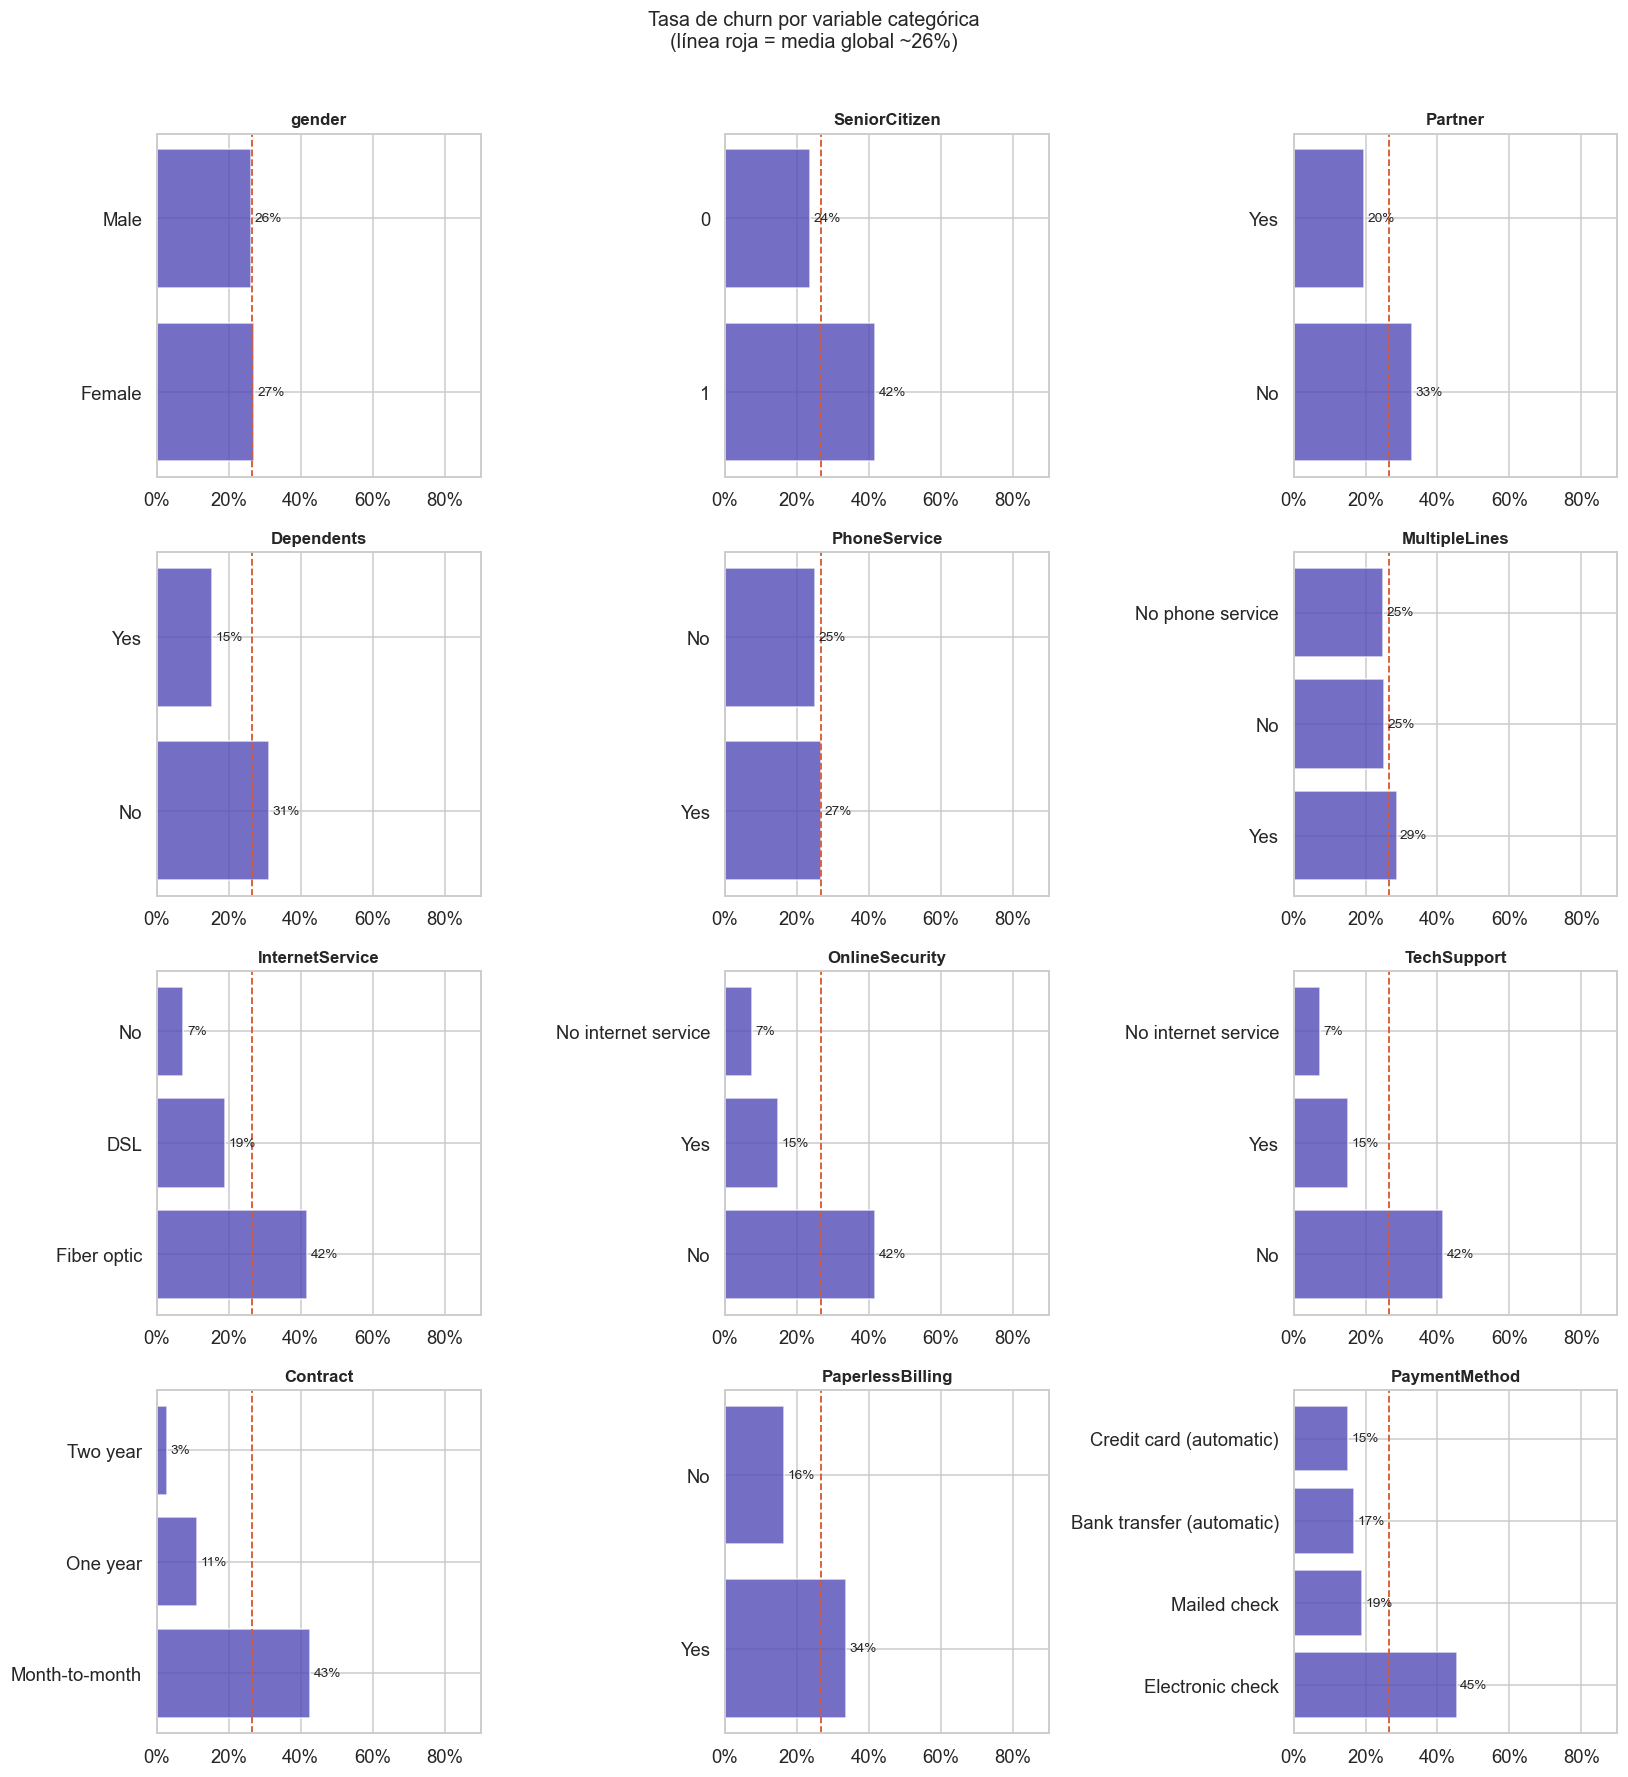

In [12]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'TechSupport', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate_cat = df.groupby(col)['Churn_bin'].mean().sort_values(ascending=False)
    bars = ax.barh(churn_rate_cat.index.astype(str),
                   churn_rate_cat.values,
                   color='#534AB7', alpha=0.8, edgecolor='white')
    ax.axvline(df['Churn_bin'].mean(), color='#D85A30',
               linestyle='--', linewidth=1.2, label='Media global')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_xlim(0, 0.9)
    for bar, val in zip(bars, churn_rate_cat.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.0%}', va='center', fontsize=9)

# Ocultar ejes sobrantes
for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle('Tasa de churn por variable categórica\n(línea roja = media global ~26%)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plot_03_categoricas_churn.png', bbox_inches='tight')
plt.show()

---
## 5. Correlación entre variables numéricas

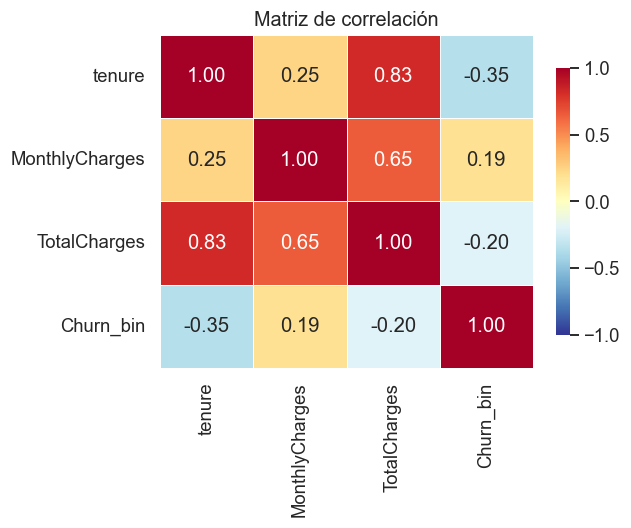

→ tenure tiene correlación NEGATIVA con Churn: más tiempo = menos probabilidad de irse
→ MonthlyCharges tiene correlación POSITIVA con Churn: cobros altos = más riesgo
→ TotalCharges está muy correlacionado con tenure (es su producto): cuidado con multicolinealidad


In [13]:
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_bin']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación', fontsize=13)
plt.tight_layout()
plt.savefig('plot_04_correlacion.png', bbox_inches='tight')
plt.show()

print('→ tenure tiene correlación NEGATIVA con Churn: más tiempo = menos probabilidad de irse')
print('→ MonthlyCharges tiene correlación POSITIVA con Churn: cobros altos = más riesgo')
print('→ TotalCharges está muy correlacionado con tenure (es su producto): cuidado con multicolinealidad')

---
## 6. Análisis del tipo de contrato (la variable más importante)



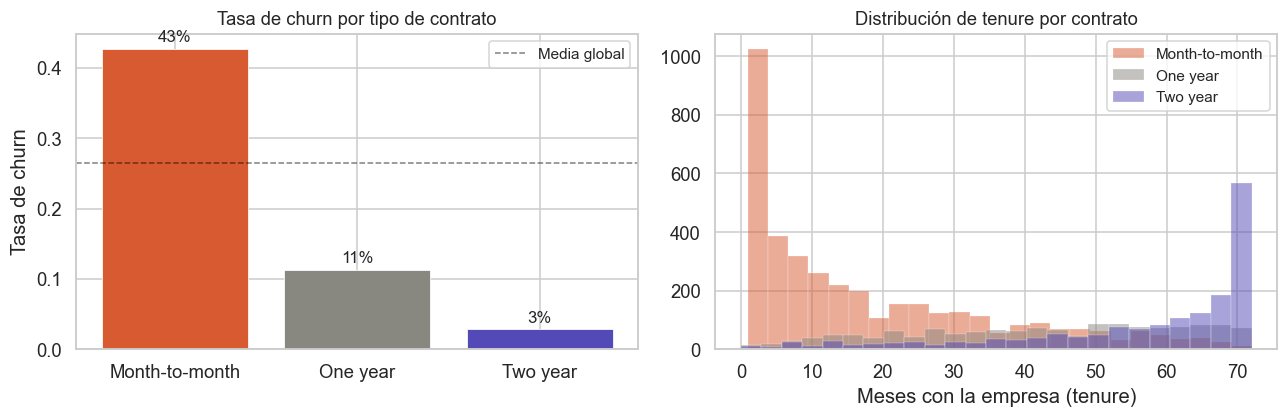

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tasa de churn por tipo de contrato
contract_churn = df.groupby('Contract')['Churn_bin'].mean().sort_values(ascending=False)
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=['#D85A30', '#888780', '#534AB7'],
                   edgecolor='white', linewidth=0.5)
axes[0].axhline(df['Churn_bin'].mean(), color='black',
                linestyle='--', linewidth=1, alpha=0.5, label='Media global')
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.0%}', ha='center', fontsize=11)
axes[0].set_title('Tasa de churn por tipo de contrato', fontsize=12)
axes[0].set_ylabel('Tasa de churn')
axes[0].legend(fontsize=10)

# Distribución de tenure según contrato y churn
for contract, color in [('Month-to-month', '#D85A30'),
                         ('One year', '#888780'),
                         ('Two year', '#534AB7')]:
    subset = df[df['Contract'] == contract]['tenure']
    axes[1].hist(subset, bins=25, alpha=0.5, label=contract,
                 color=color, edgecolor='white', linewidth=0.3)

axes[1].set_title('Distribución de tenure por contrato', fontsize=12)
axes[1].set_xlabel('Meses con la empresa (tenure)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('plot_05_contrato_churn.png', bbox_inches='tight')
plt.show()

---
## 7. Resumen: hallazgos del EDA



In [15]:
resumen = """
=== HALLAZGOS DEL EDA ===

Dataset: 7,043 clientes | 21 variables | 26.5% tasa de churn

Variables con mayor señal predictiva:

1. Contract (tipo de contrato)
   - Month-to-month: ~43% de churn
   - One year:        ~11% de churn
   - Two year:         ~3% de churn
   → La variable más discriminante con diferencia

2. tenure (meses con la empresa)
   - Clientes con churn tienen en promedio 18 meses vs 37 meses los que se quedan
   → Los primeros meses son el período crítico de retención

3. OnlineSecurity y TechSupport
   - Sin servicio: ~42% churn | Con servicio: ~15% churn
   → Los servicios de valor agregado retienen clientes

4. MonthlyCharges
   - Media clientes que se van: $74.4 | Media clientes que quedan: $61.3
   → Cargos altos sin percepción de valor = mayor riesgo

5. InternetService
   - Fiber optic: ~42% churn (el más alto)
   - DSL: ~19% | Sin internet: ~7%
   → Posible problema de satisfacción con fibra óptica

Variable sin señal:
   - gender: ~26% en ambos grupos (descartar como feature)

Problema de datos:
   - TotalCharges venía como string → convertido a numérico
   - 11 nulos en TotalCharges = clientes con tenure=0 → imputar con 0

Desbalance de clases: 73.5% / 26.5%
→ Usaremos AUC-ROC y F1-score como métricas principales, NO accuracy
"""
print(resumen)


=== HALLAZGOS DEL EDA ===

Dataset: 7,043 clientes | 21 variables | 26.5% tasa de churn

Variables con mayor señal predictiva:

1. Contract (tipo de contrato)
   - Month-to-month: ~43% de churn
   - One year:        ~11% de churn
   - Two year:         ~3% de churn
   → La variable más discriminante con diferencia

2. tenure (meses con la empresa)
   - Clientes con churn tienen en promedio 18 meses vs 37 meses los que se quedan
   → Los primeros meses son el período crítico de retención

3. OnlineSecurity y TechSupport
   - Sin servicio: ~42% churn | Con servicio: ~15% churn
   → Los servicios de valor agregado retienen clientes

4. MonthlyCharges
   - Media clientes que se van: $74.4 | Media clientes que quedan: $61.3
   → Cargos altos sin percepción de valor = mayor riesgo

5. InternetService
   - Fiber optic: ~42% churn (el más alto)
   - DSL: ~19% | Sin internet: ~7%
   → Posible problema de satisfacción con fibra óptica

Variable sin señal:
   - gender: ~26% en ambos grupos (desc